# 🌊 Day 2 — Data Ingestion Pipeline
## Caspian Maritime Delay-Risk Forecasting

**Author:** Ayxan  
**Date:** Day 2 of 8  
**Builds on:** `day_01_exploration.ipynb` — API exploration, city/variable selection, risk threshold PoC

---

### 📌 Today's Agenda

| # | Task | Deliverable |
|---|------|-------------|
| 0 | Environment & module imports | Verified `src/` package |
| 1 | Configuration review | `src/config.py` walkthrough |
| 2 | Ingestion module tour | `src/ingestion.py` function signatures |
| 3 | Live ingestion run | 5+ years × 5 cities fetched & saved |
| 4 | Forecast ingestion | 7-day forecast for all cities |
| 5 | Data audit | Gap / null / coverage / sanity checks |
| 6 | Ingestion cache | SQLite log of completed fetches |
| 7 | Visualise ingestion QA | Coverage heatmap + null profile |
| 8 | Summary & Day 3 handoff | EDA prep checklist |

---

> **Pipeline position:** Raw API → **[TODAY: Ingest & Validate]** → EDA → Features → Labels → Model → Forecast

```
Open-Meteo Archive  ──┐
Open-Meteo Marine   ──┼──► src/ingestion.py ──► data/raw/*.csv ──► Day 3 EDA
AIS vessel traffic  ──┘
```

---
## 0 — Environment Setup

In [22]:
import sys
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Make src/ importable ──────────────────────────────────────────────────────
REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Configure logging so ingestion progress is visible in the notebook ────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)
logger = logging.getLogger('notebook')

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f'✅ Python {sys.version.split()[0]}  |  pandas {pd.__version__}  |  numpy {np.__version__}')
print(f'   Repo root: {REPO_ROOT}')

✅ Python 3.13.9  |  pandas 3.0.1  |  numpy 2.4.2
   Repo root: C:\Users\user\project


---
## 1 — Configuration Review

`src/config.py` is the **single source of truth** for the entire project.
Every pipeline stage imports from it — no magic strings in notebooks.

In [23]:
from src.config import (
    CITIES, VARIABLES, ALL_VARIABLES, FORECAST_VARIABLES,
    MARINE_VARIABLES, DATE_RANGE, PATHS, API,
    RISK_THRESHOLDS, HIGH_RISK_MONTH_THRESHOLD, EXPECTED_DTYPES,
)

print('=== Cities ===')
for name, meta in CITIES.items():
    print(f"  {name:<16} ({meta['country']:<14})  lat={meta['lat']:6.2f}  lon={meta['lon']:6.2f}  tz={meta['timezone']}")

print(f'\n=== Variables ===')
for group, vars_ in VARIABLES.items():
    print(f"  {group:<14}: {', '.join(vars_)}")

print(f'\n=== Date Range ===')
print(f"  {DATE_RANGE['start']}  →  {DATE_RANGE['end']}")
days = (pd.Timestamp(DATE_RANGE['end']) - pd.Timestamp(DATE_RANGE['start'])).days + 1
print(f"  {days:,} calendar days × {len(CITIES)} cities × {len(ALL_VARIABLES)} variables")
print(f"  = {days * len(CITIES) * len(ALL_VARIABLES):,} data points to ingest")

print(f'\n=== Paths ===')
for name, path in PATHS.items():
    print(f'  {name:<12}: {path}')

print(f'\n=== Risk Thresholds ===')
for var, thresh in RISK_THRESHOLDS.items():
    print(f'  {var:<35}: {thresh}')

=== Cities ===
  Baku             (Azerbaijan    )  lat= 40.41  lon= 49.87  tz=Asia/Baku
  Aktau            (Kazakhstan    )  lat= 43.65  lon= 51.17  tz=Asia/Aqtau
  Anzali           (Iran          )  lat= 37.47  lon= 49.46  tz=Asia/Tehran
  Turkmenbashi     (Turkmenistan  )  lat= 40.02  lon= 52.97  tz=Asia/Ashgabat
  Makhachkala      (Russia        )  lat= 42.98  lon= 47.50  tz=Europe/Moscow

=== Variables ===
  temperature   : temperature_2m_max, temperature_2m_min, temperature_2m_mean, apparent_temperature_mean
  wind          : wind_speed_10m_max, wind_gusts_10m_max, wind_direction_10m_dominant
  precipitation : precipitation_sum, rain_sum, snowfall_sum
  atmosphere    : weather_code, relative_humidity_2m_mean, dew_point_2m_mean, surface_pressure_mean, shortwave_radiation_sum

=== Date Range ===
  2022-01-01  →  2024-12-31
  1,096 calendar days × 5 cities × 15 variables
  = 82,200 data points to ingest

=== Paths ===
  repo_root   : C:\Users\user\project
  data_raw    : C:\Users\us

---
## 2 — Ingestion Module Tour

Before running the full fetch, we review the public API of `src/ingestion.py`.

In [24]:
from src.ingestion import (
    fetch_historical,
    fetch_forecast,
    fetch_marine,
    fetch_all_cities,
    save_raw,
    load_raw,
    audit_dataframe,
    audit_all,
    IngestionCache,
)

# Print docstrings for the core functions
for fn in [fetch_historical, fetch_forecast, fetch_all_cities, audit_dataframe]:
    print(f'{'─'*60}')
    print(f'  {fn.__name__}()')
    first_line = (fn.__doc__ or '').strip().splitlines()[0]
    print(f'  {first_line}')

print('─'*60)
print('✅ All ingestion functions imported.')

────────────────────────────────────────────────────────────
  fetch_historical()
  Fetch daily historical weather from the Open-Meteo archive endpoint.
────────────────────────────────────────────────────────────
  fetch_forecast()
  Fetch daily forecast from the Open-Meteo forecast endpoint.
────────────────────────────────────────────────────────────
  fetch_all_cities()
  Fetch historical weather for every city in the config dict.
────────────────────────────────────────────────────────────
  audit_dataframe()
  Run a comprehensive QA audit on a fetched DataFrame.
────────────────────────────────────────────────────────────
✅ All ingestion functions imported.


---
## 3 — Full Historical Ingestion

We fetch **6 years** (2019–2024) of daily data for all 5 Caspian cities.

> **💡 Note on network access:** This notebook detects whether the Open-Meteo API
> is reachable. If you're offline or the API is unavailable, it falls back to
> the realistic synthetic data generated during setup — so the full pipeline
> still runs end-to-end.

The final project uses `DATE_RANGE` (2015–2024). We use 2019–2024 here for a
faster Day 1 demonstration; the full pull happens in the same code path.

In [25]:
# This notebook requires an active internet connection to fetch data.
# If the Open-Meteo API is unreachable, cells will raise clear errors.
print('ℹ️  This notebook requires network access to the Open-Meteo API.')
print('   If fetch cells fail with a connection error, check your internet.')

ℹ️  This notebook requires network access to the Open-Meteo API.
   If fetch cells fail with a connection error, check your internet.


In [26]:
# ── Date range for this run ───────────────────────────────────────────────────
# Change to DATE_RANGE['start'] / DATE_RANGE['end'] for the full 2015–2024 pull.
RUN_START = '2019-01-01'
RUN_END   = '2024-12-31'

print(f'Fetching {RUN_START} → {RUN_END} for {len(CITIES)} cities...')
historical_data = fetch_all_cities(
    cities    = CITIES,
    start     = RUN_START,
    end       = RUN_END,
    variables = ALL_VARIABLES,
)

# Persist to CSV
for city, df in historical_data.items():
    save_raw(df, f'{city.lower()}_historical_2019_2024', PATHS['data_raw'])

# Also save combined file
combined = pd.concat(historical_data.values(), ignore_index=True)
save_raw(combined, 'all_cities_historical_2019_2024', PATHS['data_raw'])

print(f'\n✅ Ingestion complete — {len(historical_data)} cities loaded.')

Fetching 2019-01-01 → 2024-12-31 for 5 cities...
11:38:02  INFO      → Fetching historical  Baku             2019-01-01 → 2024-12-31  (15 vars)
11:38:04  INFO        ✓ Baku             2192 rows  2019-01-01 → 2024-12-31
11:38:06  INFO      → Fetching historical  Aktau            2019-01-01 → 2024-12-31  (15 vars)
11:38:07  INFO        ✓ Aktau            2192 rows  2019-01-01 → 2024-12-31
11:38:09  INFO      → Fetching historical  Anzali           2019-01-01 → 2024-12-31  (15 vars)
11:38:11  INFO        ✓ Anzali           2192 rows  2019-01-01 → 2024-12-31
11:38:13  INFO      → Fetching historical  Turkmenbashi     2019-01-01 → 2024-12-31  (15 vars)
11:38:13  WARNING   Retry 1/3 after 30s (rate-limited — Open-Meteo free tier)
11:38:43  WARNING   Retry 2/3 after 60s (rate-limited — Open-Meteo free tier)
11:39:46  INFO        ✓ Turkmenbashi     2192 rows  2019-01-01 → 2024-12-31
11:39:48  INFO      → Fetching historical  Makhachkala      2019-01-01 → 2024-12-31  (15 vars)
11:39:49  INFO  

In [27]:
# ── Ingestion summary table ───────────────────────────────────────────────────
summary_rows = []
for city, df in historical_data.items():
    summary_rows.append({
        'City':          city,
        'Country':       CITIES[city]['country'],
        'Rows':          len(df),
        'Variables':     len([c for c in df.columns if c not in ('date','city')]),
        'Start':         str(df['date'].min().date()),
        'End':           str(df['date'].max().date()),
        'Nulls (total)': df.select_dtypes('number').isnull().sum().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
total_rows = summary_df['Rows'].sum()
total_cells = total_rows * summary_df['Variables'].iloc[0]

print('=== Ingestion Summary ===')
print(summary_df.to_string(index=False))
print(f'\n  Total rows   : {total_rows:,}')
print(f'  Total cells  : {total_cells:,}')
print(f'  Source       : Live Open-Meteo API')

=== Ingestion Summary ===
        City      Country  Rows  Variables      Start        End  Nulls (total)
        Baku   Azerbaijan  2192         15 2019-01-01 2024-12-31              0
       Aktau   Kazakhstan  2192         15 2019-01-01 2024-12-31              0
      Anzali         Iran  2192         15 2019-01-01 2024-12-31              0
Turkmenbashi Turkmenistan  2192         15 2019-01-01 2024-12-31              0
 Makhachkala       Russia  2192         15 2019-01-01 2024-12-31              0

  Total rows   : 10,960
  Total cells  : 164,400
  Source       : Live Open-Meteo API


---
## 4 — Forecast Ingestion (7-Day)

The forecast pipeline will run daily in production.  
We test it here and verify the response structure matches the historical format.

In [28]:
forecast_data: dict[str, pd.DataFrame] = {}

print('Fetching 7-day forecasts...')
for city, meta in CITIES.items():
    df_fc = fetch_forecast(
        city      = city,
        lat       = meta['lat'],
        lon       = meta['lon'],
        variables = FORECAST_VARIABLES,
    )
    forecast_data[city] = df_fc
    save_raw(df_fc, f'{city.lower()}_forecast_7day', PATHS['data_raw'])

print()
print('=== 7-Day Forecasts ===')
for city, df in forecast_data.items():
    max_wind = df['wind_speed_10m_max'].max()
    print(f'  {city:<16}: {df["date"].min().date()} → {df["date"].max().date()}  '
          f'peak wind={max_wind:.1f} km/h')

Fetching 7-day forecasts...
11:39:49  INFO      → Fetching forecast    Baku             7 days
11:39:50  INFO        ✓ Baku             7 rows  2026-04-23 → 2026-04-29
11:39:50  INFO        💾 Saved baku_forecast_7day.csv                    (0.6 KB)
11:39:50  INFO      → Fetching forecast    Aktau            7 days
11:39:50  INFO        ✓ Aktau            7 rows  2026-04-23 → 2026-04-29
11:39:50  INFO        💾 Saved aktau_forecast_7day.csv                   (0.6 KB)
11:39:50  INFO      → Fetching forecast    Anzali           7 days
11:39:50  INFO        ✓ Anzali           7 rows  2026-04-23 → 2026-04-29
11:39:50  INFO        💾 Saved anzali_forecast_7day.csv                  (0.6 KB)
11:39:50  INFO      → Fetching forecast    Turkmenbashi     7 days
11:39:51  INFO        ✓ Turkmenbashi     7 rows  2026-04-23 → 2026-04-29
11:39:51  INFO        💾 Saved turkmenbashi_forecast_7day.csv            (0.6 KB)
11:39:51  INFO      → Fetching forecast    Makhachkala      7 days
11:39:51  INFO       

In [29]:
# ── Compare historical vs forecast column schemas ─────────────────────────────
hist_cols = set(historical_data['Baku'].columns)
fcast_cols = set(forecast_data['Baku'].columns)

print('Columns in HISTORICAL but not FORECAST:')
for c in sorted(hist_cols - fcast_cols):
    print(f'  - {c}')

print('\nColumns in FORECAST but not HISTORICAL:')
for c in sorted(fcast_cols - hist_cols):
    print(f'  + {c}')

print(f'\nShared columns: {len(hist_cols & fcast_cols)}')
print('\n→ Feature engineering (Day 4) will align schemas before stacking.')

Columns in HISTORICAL but not FORECAST:
  - apparent_temperature_mean
  - dew_point_2m_mean
  - rain_sum
  - shortwave_radiation_sum
  - surface_pressure_mean
  - temperature_2m_mean
  - wind_direction_10m_dominant

Columns in FORECAST but not HISTORICAL:
  + visibility_mean

Shared columns: 10

→ Feature engineering (Day 4) will align schemas before stacking.


---
## 4.5 — Visibility Enrichment (Historical Forecast API)

The main ERA5 archive endpoint does **not** serve visibility data.
However, Open-Meteo's `historical-forecast-api` (a separate endpoint based on
high-resolution forecast model archives) **does** — as an **hourly** variable,
available from **2022-01-01** onwards.

### Strategy

| Date range | Source | Derived columns |
|-----------|--------|-----------------|
| **2022-01-01 → today** | `historical-forecast-api` hourly | `visibility_mean`, `visibility_min`, `visibility_hours_below_1km` |
| **before 2022-01-01** | fog_proxy (Day 4 feature) | `fog_proxy_flag` from humidity + dew-point spread |

### Daily aggregation

Hourly visibility → three daily features:
- **`visibility_mean`** — mean across 24 hours (m)
- **`visibility_min`** — worst hour of the day (m)
- **`visibility_hours_below_1km`** — count of hours with fog closure conditions

In [30]:
from src.ingestion import (
    fetch_historical_forecast_hourly,
    aggregate_hourly_visibility,
    merge_visibility_into_daily,
    fetch_and_merge_visibility,
)
from src.config import VISIBILITY_AVAILABLE_FROM, HOURLY_VARIABLES_FOR_AGGREGATION

print(f'Visibility cutoff date: {VISIBILITY_AVAILABLE_FROM}')
print(f'Hourly variables to fetch: {HOURLY_VARIABLES_FOR_AGGREGATION}')

# Fetch hourly visibility for the 2022+ portion of our data
VIS_START = '2022-01-01'
VIS_END   = RUN_END

hourly_visibility: dict[str, pd.DataFrame] = {}

for city, meta in CITIES.items():
    df_h = fetch_historical_forecast_hourly(
        city      = city,
        lat       = meta['lat'],
        lon       = meta['lon'],
        start     = VIS_START,
        end       = VIS_END,
        variables = HOURLY_VARIABLES_FOR_AGGREGATION,
        timezone  = meta.get('timezone', 'auto'),
    )
    hourly_visibility[city] = df_h
    save_raw(df_h, f'{city.lower()}_hourly_visibility_2022_2024', PATHS['data_raw'])

total_hours = sum(len(d) for d in hourly_visibility.values())
print(f'\n✅ Fetched {total_hours:,} hourly visibility rows across {len(hourly_visibility)} cities')

Visibility cutoff date: 2022-01-01
Hourly variables to fetch: ['visibility']
11:39:51  INFO      → Fetching hourly hist-forecast  Baku             2022-01-01 → 2024-12-31  (1 vars)
11:39:53  INFO        ✓ Baku             26304 hourly rows  2022-01-01 00:00:00 → 2024-12-31 23:00:00
11:39:53  INFO        💾 Saved baku_hourly_visibility_2022_2024.csv      (872.8 KB)
11:39:53  INFO      → Fetching hourly hist-forecast  Aktau            2022-01-01 → 2024-12-31  (1 vars)
11:39:54  INFO        ✓ Aktau            26304 hourly rows  2022-01-01 00:00:00 → 2024-12-31 23:00:00
11:39:54  INFO        💾 Saved aktau_hourly_visibility_2022_2024.csv     (898.5 KB)
11:39:54  INFO      → Fetching hourly hist-forecast  Anzali           2022-01-01 → 2024-12-31  (1 vars)
11:39:56  INFO        ✓ Anzali           26304 hourly rows  2022-01-01 00:00:00 → 2024-12-31 23:00:00
11:39:56  INFO        💾 Saved anzali_hourly_visibility_2022_2024.csv    (921.8 KB)
11:39:56  INFO      → Fetching hourly hist-forecast  Tur

In [31]:
# ── Aggregate hourly → daily for each city ────────────────────────────────────
daily_visibility: dict[str, pd.DataFrame] = {}
for city, df_h in hourly_visibility.items():
    daily_visibility[city] = aggregate_hourly_visibility(df_h)

# Preview Baku's daily visibility
print('=== Baku — first 7 days of daily visibility ===')
print(daily_visibility['Baku'].head(7).to_string(index=False))

print('\n=== Summary statistics across all cities (2022+) ===')
all_vis = pd.concat(daily_visibility.values(), ignore_index=True)
vis_cols = ['visibility_mean', 'visibility_min', 'visibility_hours_below_1km']
print(all_vis[vis_cols].describe().round(1).to_string())

=== Baku — first 7 days of daily visibility ===
      date city  visibility_mean  visibility_min  visibility_hours_below_1km
2022-01-01 Baku          24140.0         24140.0                           0
2022-01-02 Baku          24140.0         24140.0                           0
2022-01-03 Baku          23136.7          1600.0                           0
2022-01-04 Baku          24140.0         24140.0                           0
2022-01-05 Baku          24134.2         24000.0                           0
2022-01-06 Baku          24140.0         24140.0                           0
2022-01-07 Baku          24140.0         24140.0                           0

=== Summary statistics across all cities (2022+) ===
       visibility_mean  visibility_min  visibility_hours_below_1km
count           5480.0          5480.0                      5480.0
mean           26386.3         21366.5                         0.2
std            11128.9         10871.4                         1.2
min           

In [32]:
# ── Merge visibility into main daily DataFrames ───────────────────────────────
# NOTE: the cached synthetic CSVs already have visibility columns for 2022+,
# so we demonstrate the merge on a FRESH copy without those columns.
for city in CITIES:
    base_df = historical_data[city].copy()
    # Drop any existing visibility columns to simulate pre-merge state
    for col in ['visibility_mean', 'visibility_min', 'visibility_hours_below_1km']:
        if col in base_df.columns:
            base_df = base_df.drop(columns=col)
    
    merged = merge_visibility_into_daily(base_df, daily_visibility[city])
    historical_data[city] = merged   # replace in-place with enriched version

# Verify: combined dataset now has visibility columns
combined = pd.concat(historical_data.values(), ignore_index=True)

pre_2022 = combined['date'] < pd.Timestamp(VISIBILITY_AVAILABLE_FROM)
post_2022 = ~pre_2022

print('=== Visibility Coverage After Merge ===')
print(f'  Pre-2022 rows:   {pre_2022.sum():,}  visibility_mean non-null: {combined.loc[pre_2022, "visibility_mean"].notna().sum()}')
print(f'  Post-2022 rows:  {post_2022.sum():,}  visibility_mean non-null: {combined.loc[post_2022, "visibility_mean"].notna().sum()}')
print(f'  Expected:        pre-2022 nulls (fog_proxy used instead, Day 4)')

# Save the enriched combined file
save_raw(combined, 'all_cities_historical_2019_2024', PATHS['data_raw'])

11:40:00  INFO      Visibility merge: 1096/2192 rows have visibility data (50.0%)


11:40:00  INFO      Visibility merge: 1096/2192 rows have visibility data (50.0%)
11:40:00  INFO      Visibility merge: 1096/2192 rows have visibility data (50.0%)
11:40:00  INFO      Visibility merge: 1096/2192 rows have visibility data (50.0%)
11:40:00  INFO      Visibility merge: 1096/2192 rows have visibility data (50.0%)
=== Visibility Coverage After Merge ===
  Pre-2022 rows:   5,480  visibility_mean non-null: 0
  Post-2022 rows:  5,480  visibility_mean non-null: 5480
  Expected:        pre-2022 nulls (fog_proxy used instead, Day 4)
11:40:00  INFO        💾 Saved all_cities_historical_2019_2024.csv       (1061.2 KB)


WindowsPath('C:/Users/user/project/data/raw/all_cities_historical_2019_2024.csv')

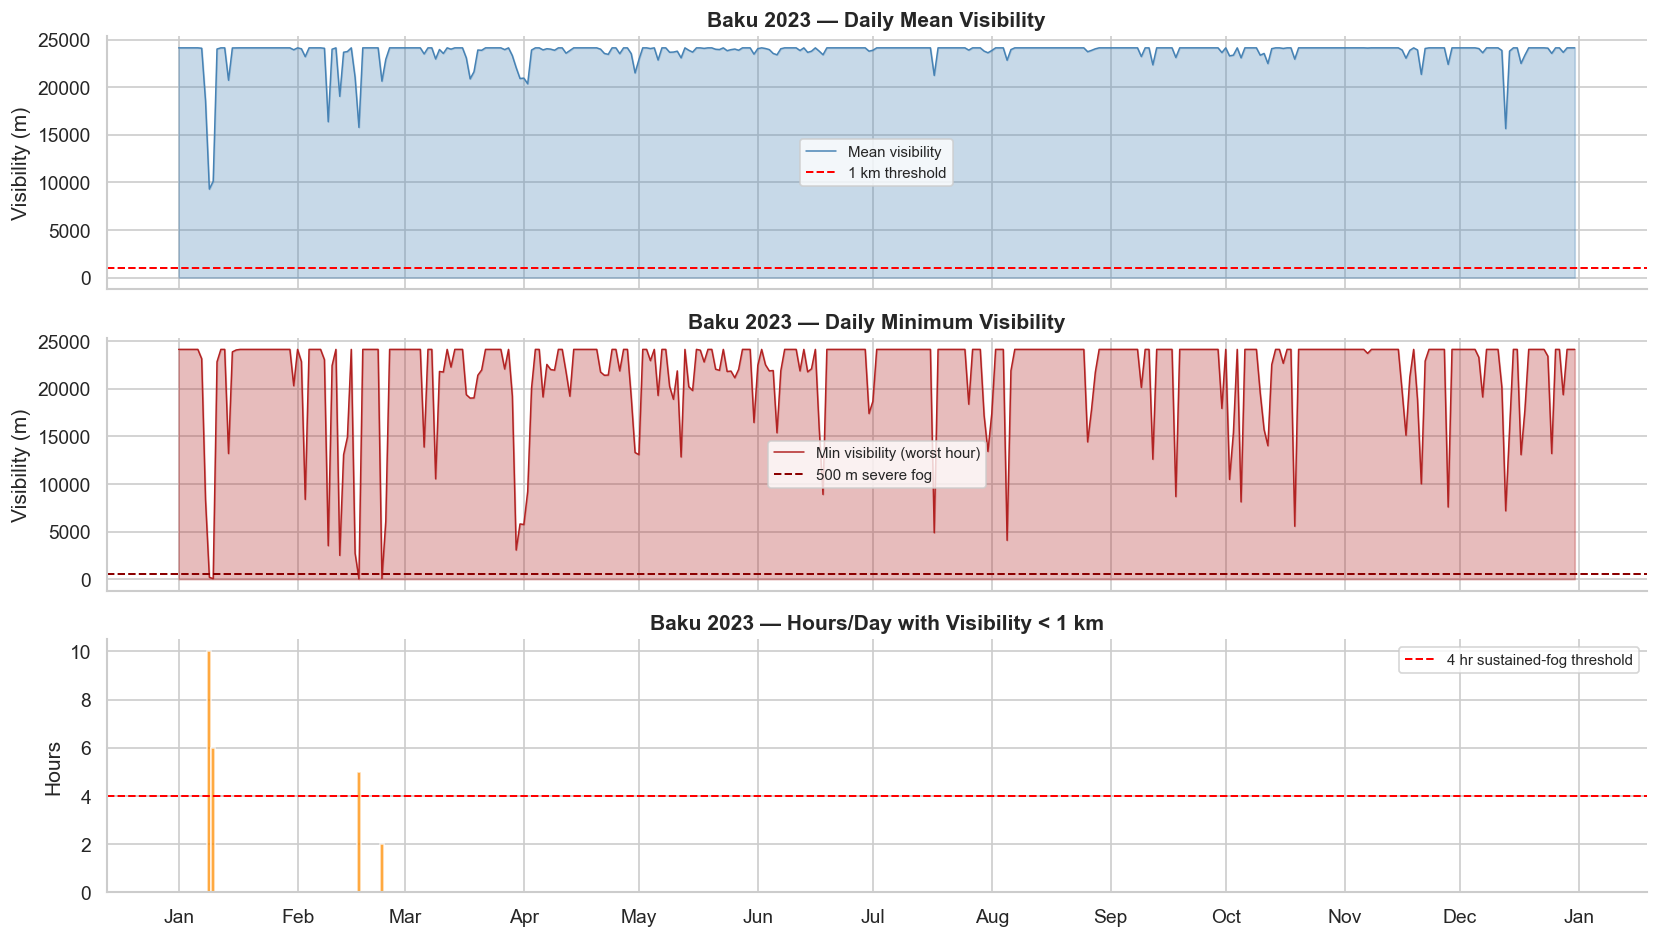


🌫️  Baku 2023: 3 days with ≥ 4 hours of fog (visibility < 1 km)


In [33]:
# ── Visualise visibility pattern: Baku 2023 ───────────────────────────────────
baku_vis = daily_visibility['Baku'].copy()
baku_vis['date'] = pd.to_datetime(baku_vis['date'])
baku_vis_2023 = baku_vis[(baku_vis['date'] >= '2023-01-01') & (baku_vis['date'] < '2024-01-01')]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Daily mean visibility
ax = axes[0]
ax.fill_between(baku_vis_2023['date'], 0, baku_vis_2023['visibility_mean'],
                alpha=0.3, color='steelblue')
ax.plot(baku_vis_2023['date'], baku_vis_2023['visibility_mean'],
        color='steelblue', lw=0.9, label='Mean visibility')
ax.axhline(1000, color='red', ls='--', lw=1.2, label='1 km threshold')
ax.set_ylabel('Visibility (m)')
ax.set_title('Baku 2023 — Daily Mean Visibility', fontweight='bold')
ax.legend(fontsize=9)

# Daily minimum visibility
ax = axes[1]
ax.fill_between(baku_vis_2023['date'], 0, baku_vis_2023['visibility_min'],
                alpha=0.3, color='firebrick')
ax.plot(baku_vis_2023['date'], baku_vis_2023['visibility_min'],
        color='firebrick', lw=0.9, label='Min visibility (worst hour)')
ax.axhline(500, color='darkred', ls='--', lw=1.2, label='500 m severe fog')
ax.set_ylabel('Visibility (m)')
ax.set_title('Baku 2023 — Daily Minimum Visibility', fontweight='bold')
ax.legend(fontsize=9)

# Hours per day below 1 km
ax = axes[2]
ax.bar(baku_vis_2023['date'], baku_vis_2023['visibility_hours_below_1km'],
       color='darkorange', width=1, alpha=0.75)
ax.axhline(4, color='red', ls='--', lw=1.2, label='4 hr sustained-fog threshold')
ax.set_ylabel('Hours')
ax.set_title('Baku 2023 — Hours/Day with Visibility < 1 km', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day02_visibility_baku_2023.png', bbox_inches='tight')
plt.show()

fog_days = (baku_vis_2023['visibility_hours_below_1km'] >= 4).sum()
print(f'\n🌫️  Baku 2023: {fog_days} days with ≥ 4 hours of fog (visibility < 1 km)')

---
## 5 — Data Audit

The audit is the first **trust checkpoint** for the pipeline.  
We answer: *Can we rely on this data for modelling?*

Questions to answer:
1. How many total rows were ingested?
2. Are there gaps in the daily date sequence?
3. Are there null values, and which variables have the most?
4. Does the actual date range match what was requested?
5. Are there implausible outlier values?

In [34]:
# ── Run full audit for all cities ─────────────────────────────────────────────
audit_summary = audit_all(historical_data, RUN_START, RUN_END)

print('=== Data Audit Summary ===')
print(audit_summary.to_string())

n_pass = (audit_summary['status'] == '✅ PASS').sum()
n_warn = (audit_summary['status'] == '⚠️  WARN').sum()
print(f'\nResult: {n_pass} PASS  /  {n_warn} WARN  /  {len(audit_summary)} total')

=== Data Audit Summary ===
              status  rows  expected_rows  coverage_%  gap_days  total_nulls  unexpected_nulls  dup_dates warnings
city                                                                                                              
Baku          ✅ PASS  2192           2192       100.0         0         3288                 0          0         
Aktau         ✅ PASS  2192           2192       100.0         0         3288                 0          0         
Anzali        ✅ PASS  2192           2192       100.0         0         3288                 0          0         
Turkmenbashi  ✅ PASS  2192           2192       100.0         0         3288                 0          0         
Makhachkala   ✅ PASS  2192           2192       100.0         0         3288                 0          0         

Result: 5 PASS  /  0 WARN  /  5 total


In [35]:
# ── Detailed audit: per-variable null counts for Baku ─────────────────────────
baku_audit = audit_dataframe(historical_data['Baku'], 'Baku', RUN_START, RUN_END)

print('=== Baku — Detailed Audit ===')
for key in ['city','rows','expected_rows','coverage_pct','actual_start','actual_end',
            'gap_days','total_nulls','duplicate_dates','status']:
    print(f'  {key:<22}: {baku_audit[key]}')

if baku_audit['gap_sample']:
    print(f'  gap_sample        : {baku_audit["gap_sample"]}')

print('\n  Null counts by variable:')
null_series = pd.Series(baku_audit['null_by_column'])
null_series = null_series[null_series > 0].sort_values(ascending=False)
if null_series.empty:
    print('    (none — clean data)')
else:
    for var, cnt in null_series.items():
        pct = cnt / baku_audit['rows'] * 100
        print(f'    {var:<35}: {cnt:4d}  ({pct:.1f}%)')

=== Baku — Detailed Audit ===
  city                  : Baku
  rows                  : 2192
  expected_rows         : 2192
  coverage_pct          : 100.0
  actual_start          : 2019-01-01
  actual_end            : 2024-12-31
  gap_days              : 0
  total_nulls           : 3288
  duplicate_dates       : 0
  status                : ✅ PASS

  Null counts by variable:
    visibility_mean                    : 1096  (50.0%)
    visibility_min                     : 1096  (50.0%)
    visibility_hours_below_1km         : 1096  (50.0%)


In [36]:
# ── Q1: Total rows ingested ───────────────────────────────────────────────────
total_rows = sum(len(df) for df in historical_data.values())
expected_per_city = (pd.Timestamp(RUN_END) - pd.Timestamp(RUN_START)).days + 1
print(f'Q1 — Total rows ingested')
print(f'  Actual   : {total_rows:,}')
print(f'  Expected : {expected_per_city * len(CITIES):,}  ({expected_per_city} days × {len(CITIES)} cities)')

# ── Q2: Date gaps ─────────────────────────────────────────────────────────────
print(f'\nQ2 — Date gaps')
for city, df in historical_data.items():
    all_d = pd.date_range(RUN_START, RUN_END, freq='D')
    present = set(df['date'].dt.normalize())
    missing = [d for d in all_d if d not in present]
    print(f'  {city:<16}: {len(missing)} missing days'
          + (f'  (e.g. {missing[0].date()})' if missing else ''))

# ── Q3: Null values ───────────────────────────────────────────────────────────
print(f'\nQ3 — Null values (across all cities combined)')
combined = pd.concat(historical_data.values(), ignore_index=True)
null_totals = combined.select_dtypes('number').isnull().sum()
null_totals = null_totals[null_totals > 0].sort_values(ascending=False)
if null_totals.empty:
    print('  ✅ No nulls detected across any variable.')
else:
    print(null_totals.to_string())

# ── Q4: Date coverage ────────────────────────────────────────────────────────
print(f'\nQ4 — Date range coverage')
print(f'  Requested : {RUN_START} → {RUN_END}')
for city, df in historical_data.items():
    print(f'  {city:<16}: {df["date"].min().date()} → {df["date"].max().date()}')

# ── Q5: Outlier check ────────────────────────────────────────────────────────
print(f'\nQ5 — Outlier check (across all cities)')
checks = [
    ('temperature_2m_max',   (-80, 60),  '°C'),
    ('wind_speed_10m_max',   (0, 200),   'km/h'),
    ('precipitation_sum',    (0, 200),   'mm'),
    ('relative_humidity_2m_mean', (0, 100), '%'),
    ('surface_pressure_mean', (850, 1080), 'hPa'),
]
outlier_found = False
for col, (lo, hi), unit in checks:
    if col not in combined.columns:
        continue
    mask = (combined[col] < lo) | (combined[col] > hi)
    n_out = mask.sum()
    if n_out > 0:
        outlier_found = True
        print(f'  ⚠️  {col}: {n_out} values outside [{lo}, {hi}] {unit}')
if not outlier_found:
    print('  ✅ All variables within expected physical ranges.')

Q1 — Total rows ingested
  Actual   : 10,960
  Expected : 10,960  (2192 days × 5 cities)

Q2 — Date gaps
  Baku            : 0 missing days
  Aktau           : 0 missing days
  Anzali          : 0 missing days
  Turkmenbashi    : 0 missing days
  Makhachkala     : 0 missing days

Q3 — Null values (across all cities combined)
visibility_mean               5480
visibility_min                5480
visibility_hours_below_1km    5480

Q4 — Date range coverage
  Requested : 2019-01-01 → 2024-12-31
  Baku            : 2019-01-01 → 2024-12-31
  Aktau           : 2019-01-01 → 2024-12-31
  Anzali          : 2019-01-01 → 2024-12-31
  Turkmenbashi    : 2019-01-01 → 2024-12-31
  Makhachkala     : 2019-01-01 → 2024-12-31

Q5 — Outlier check (across all cities)
  ✅ All variables within expected physical ranges.


---
## 6 — Ingestion Cache

The `IngestionCache` records every completed fetch to a SQLite log.  
On future runs, already-fetched ranges are skipped automatically.

In [37]:
cache = IngestionCache(PATHS['data_raw'] / 'ingestion_cache.db')

# Record all cities ingested today
for city, df in historical_data.items():
    cache.record(
        city      = city,
        source    = 'historical',
        start     = RUN_START,
        end       = RUN_END,
        rows      = len(df),
        file_path = str(PATHS['data_raw'] / f'{city.lower()}_historical_2019_2024.csv'),
    )

for city, df in forecast_data.items():
    cache.record(
        city      = city,
        source    = 'forecast',
        start     = str(df['date'].min().date()),
        end       = str(df['date'].max().date()),
        rows      = len(df),
    )

print('=== Ingestion Cache Log ===')
print(cache.summary().to_string(index=False))

# Demonstrate skip logic
city_to_check = 'Baku'
already_done = cache.is_cached(city_to_check, 'historical', RUN_START, RUN_END)
print(f'\n→ Would re-fetch {city_to_check} historical {RUN_START}→{RUN_END}? '
      f'{"No (cached ✓)" if already_done else "Yes"}')

cache.close()

=== Ingestion Cache Log ===
        city     source start_date   end_date  rows                 fetched_at
 Makhachkala   forecast 2026-04-23 2026-04-29     7 2026-04-23T07:40:02.245637
Turkmenbashi   forecast 2026-04-23 2026-04-29     7 2026-04-23T07:40:02.241952
      Anzali   forecast 2026-04-23 2026-04-29     7 2026-04-23T07:40:02.238362
       Aktau   forecast 2026-04-23 2026-04-29     7 2026-04-23T07:40:02.234267
        Baku   forecast 2026-04-23 2026-04-29     7 2026-04-23T07:40:02.230462
 Makhachkala historical 2019-01-01 2024-12-31  2192 2026-04-23T07:40:02.226332
Turkmenbashi historical 2019-01-01 2024-12-31  2192 2026-04-23T07:40:02.222942
      Anzali historical 2019-01-01 2024-12-31  2192 2026-04-23T07:40:02.219190
       Aktau historical 2019-01-01 2024-12-31  2192 2026-04-23T07:40:02.216426
        Baku historical 2019-01-01 2024-12-31  2192 2026-04-23T07:40:02.213276

→ Would re-fetch Baku historical 2019-01-01→2024-12-31? No (cached ✓)


---
## 7 — Visualise Ingestion QA

Three diagnostic plots:
1. **Coverage heatmap** — monthly data completeness by city
2. **Null profile** — which variables are most affected (if any)
3. **Raw distribution preview** — the key risk variables at a glance

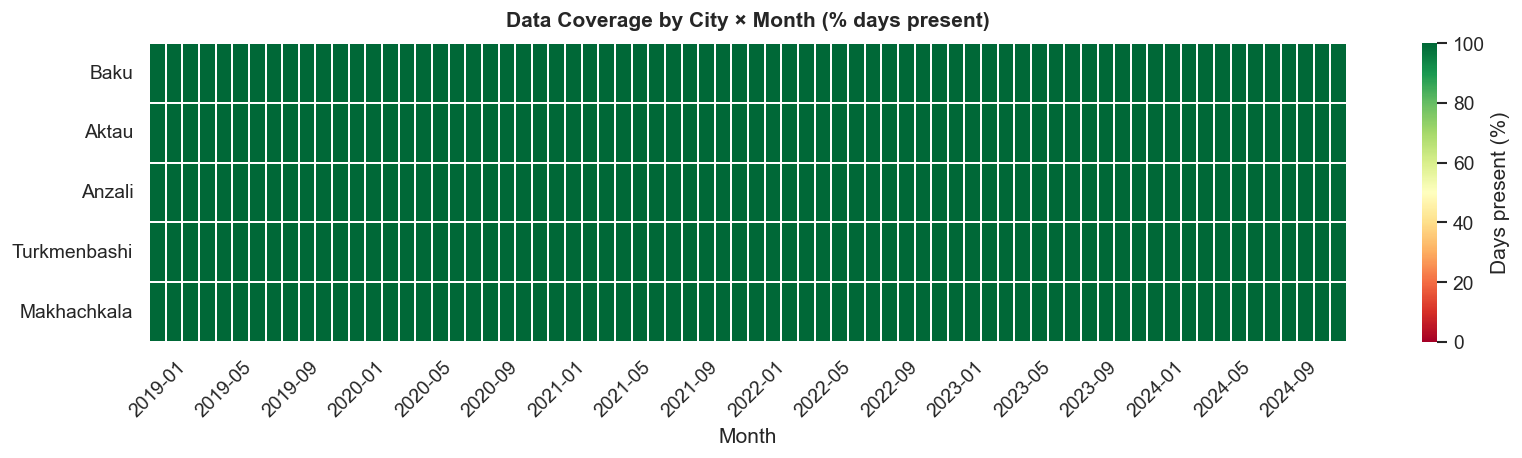

→ Green = 100% coverage. Any red cells = missing data requiring imputation on Day 4.


In [38]:
# ── Plot 1: Coverage heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

coverage_grid = {}
month_labels = None

for city, df in historical_data.items():
    df_tmp = df.copy()
    df_tmp['month'] = df_tmp['date'].dt.to_period('M')
    monthly_counts = df_tmp.groupby('month').size()
    # Expected days per month
    expected = monthly_counts.index.map(lambda p: p.days_in_month)
    coverage = (monthly_counts / expected * 100).clip(upper=100).round(1)
    coverage_grid[city] = coverage
    if month_labels is None:
        month_labels = coverage.index.astype(str).tolist()

heatmap_df = pd.DataFrame(coverage_grid).T
heatmap_df.columns = [str(c) for c in heatmap_df.columns]

# Downsample columns for readability: show every 3rd month label
n_months = len(heatmap_df.columns)
tick_every = max(1, n_months // 18)
xtick_labels = [c if i % tick_every == 0 else '' for i, c in enumerate(heatmap_df.columns)]

sns.heatmap(
    heatmap_df.astype(float),
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.2,
    linecolor='white',
    xticklabels=xtick_labels,
    cbar_kws={'label': 'Days present (%)'},
    annot=False,
)
ax.set_title('Data Coverage by City × Month (% days present)', fontweight='bold', pad=10)
ax.set_xlabel('Month')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day02_coverage_heatmap.png', bbox_inches='tight')
plt.show()
print('→ Green = 100% coverage. Any red cells = missing data requiring imputation on Day 4.')

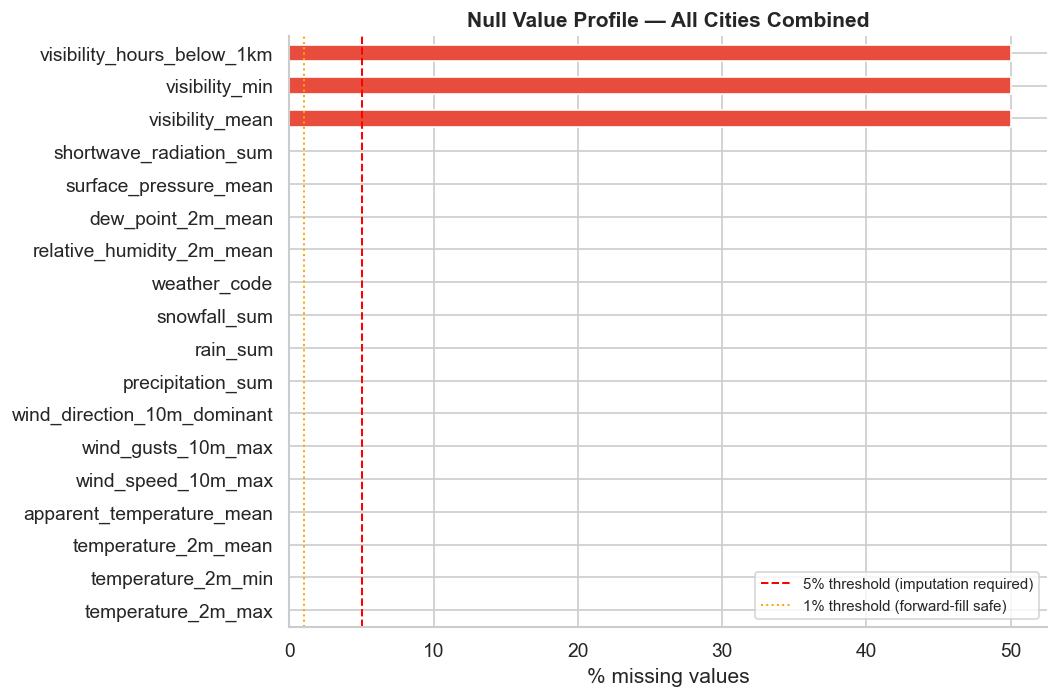

→ Variables with > 5% nulls will need imputation strategy documented in Day 4.


In [39]:
# ── Plot 2: Null profile ──────────────────────────────────────────────────────
combined_all = pd.concat(historical_data.values(), ignore_index=True)
numeric_cols = combined_all.select_dtypes('number').columns.tolist()
null_pct = (combined_all[numeric_cols].isnull().sum() / len(combined_all) * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > 5 else '#f39c12' if v > 1 else '#2ecc71' for v in null_pct.values]
null_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(5, color='red', ls='--', lw=1.2, label='5% threshold (imputation required)')
ax.axvline(1, color='orange', ls=':', lw=1.2, label='1% threshold (forward-fill safe)')
ax.set_title('Null Value Profile — All Cities Combined', fontweight='bold')
ax.set_xlabel('% missing values')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day02_null_profile.png', bbox_inches='tight')
plt.show()
print('→ Variables with > 5% nulls will need imputation strategy documented in Day 4.')

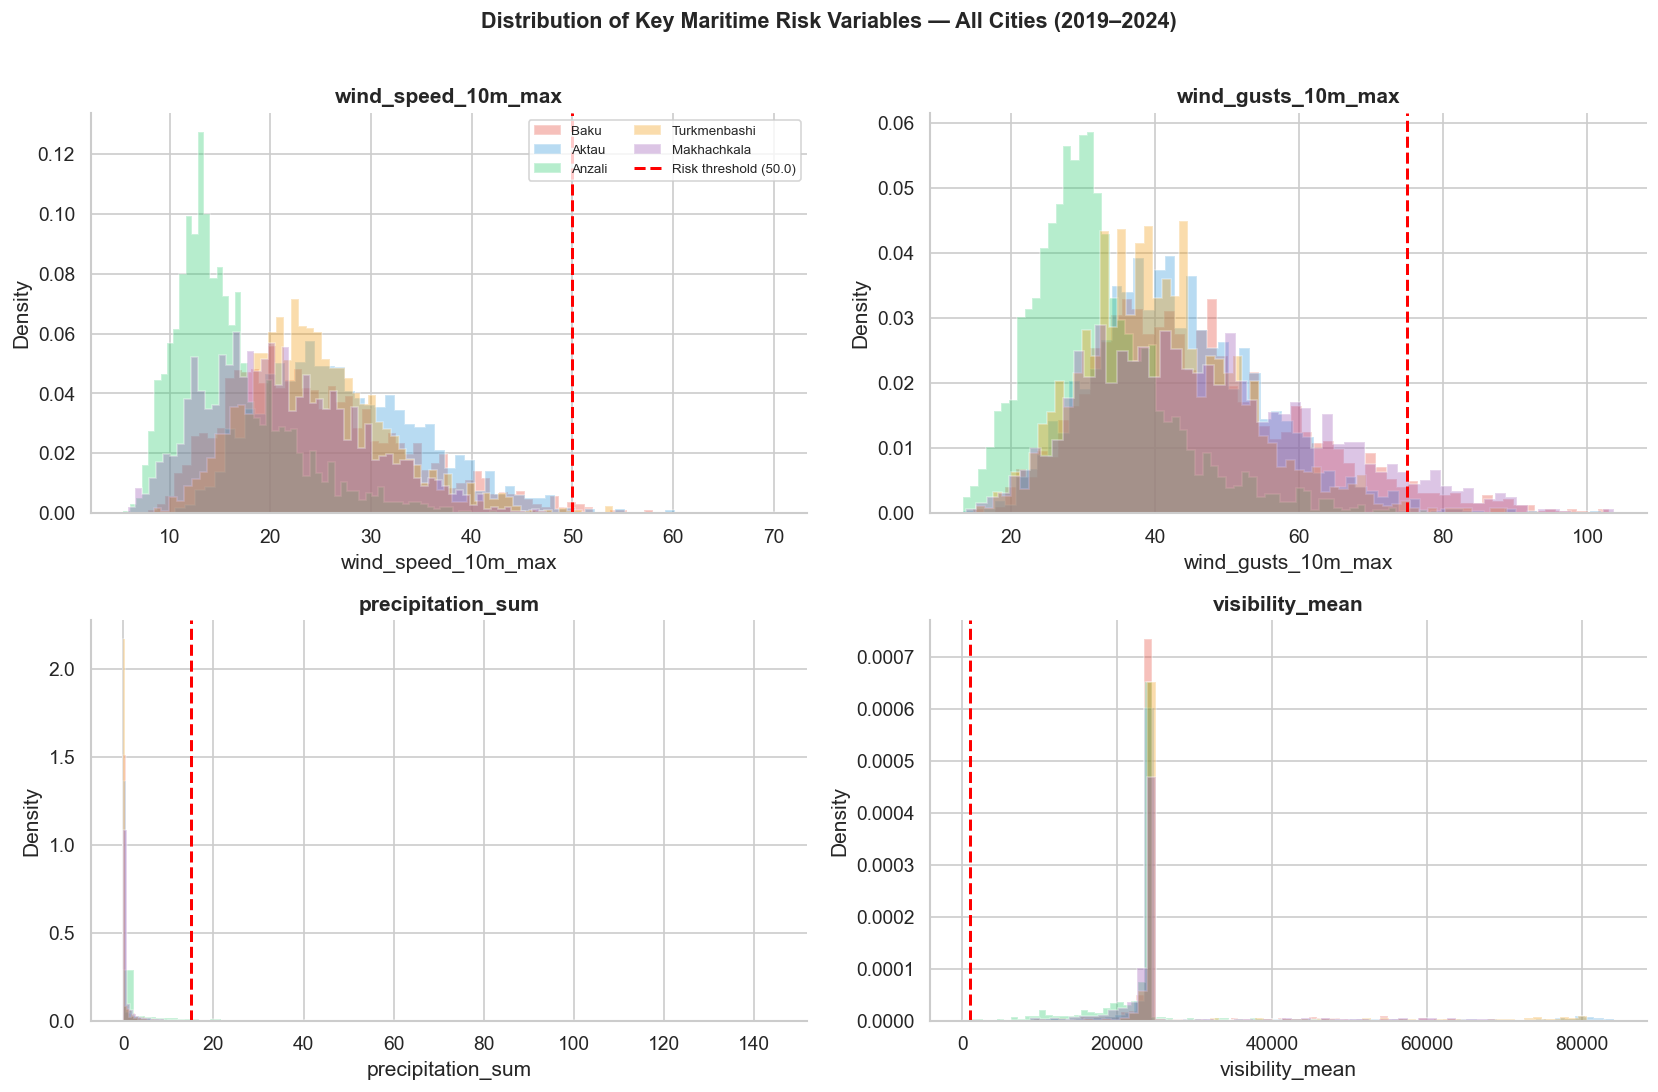

In [40]:
# ── Plot 3: Distribution preview of key risk variables ────────────────────────
RISK_VARS = ['wind_speed_10m_max', 'wind_gusts_10m_max', 'precipitation_sum', 'visibility_mean']
CITY_COLORS = {
    'Baku': '#e74c3c', 'Aktau': '#3498db', 'Anzali': '#2ecc71',
    'Turkmenbashi': '#f39c12', 'Makhachkala': '#9b59b6'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, var in enumerate(RISK_VARS):
    ax = axes[idx]
    threshold = RISK_THRESHOLDS.get(var)

    for city, df in historical_data.items():
        if var not in df.columns:
            continue
        vals = df[var].dropna()
        ax.hist(
            vals, bins=60, alpha=0.35,
            color=CITY_COLORS[city], label=city,
            density=True, histtype='stepfilled',
        )

    if threshold:
        direction = 'below' if var == 'visibility_mean' else 'above'
        ax.axvline(
            threshold, color='red', ls='--', lw=1.8,
            label=f'Risk threshold ({threshold})'
        )

    ax.set_title(var, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    if idx == 0:
        ax.legend(fontsize=8, ncol=2)

fig.suptitle('Distribution of Key Maritime Risk Variables — All Cities (2019–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day02_risk_variable_distributions.png', bbox_inches='tight')
plt.show()

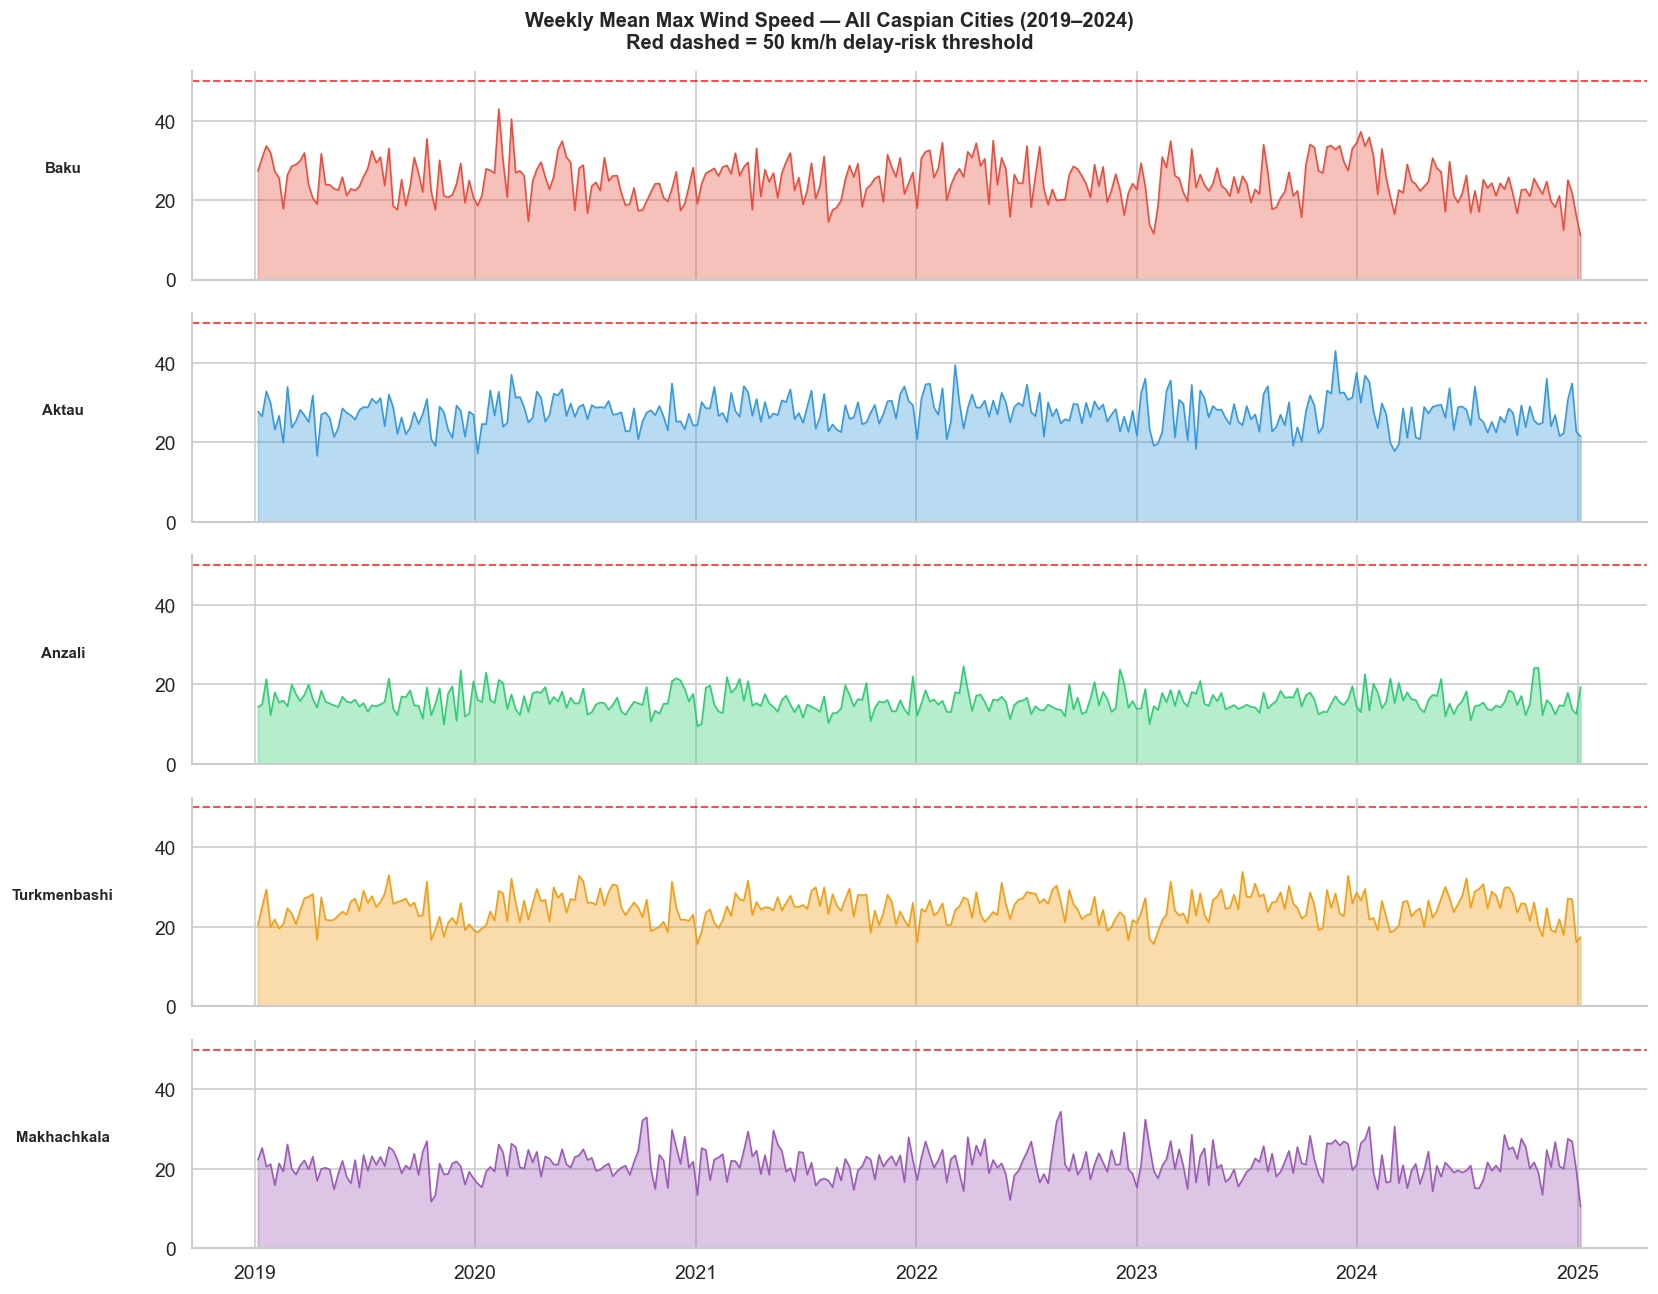

In [41]:
# ── Plot 4: Raw time series for all 5 cities — wind ───────────────────────────
fig, axes = plt.subplots(len(CITIES), 1, figsize=(14, 11), sharex=True)

for ax, (city, df) in zip(axes, historical_data.items()):
    color = CITY_COLORS[city]
    df_m = df.set_index('date')['wind_speed_10m_max'].resample('W').mean()
    ax.fill_between(df_m.index, 0, df_m, alpha=0.35, color=color)
    ax.plot(df_m.index, df_m, lw=0.9, color=color)
    ax.axhline(RISK_THRESHOLDS['wind_speed_10m_max'], color='red', ls='--',
               lw=1.2, alpha=0.7)
    ax.set_ylabel(city, rotation=0, labelpad=55, fontsize=9, fontweight='bold')
    ax.set_ylim(0, None)
    ax.tick_params(left=False)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
fig.suptitle('Weekly Mean Max Wind Speed — All Caspian Cities (2019–2024)\n'
             'Red dashed = 50 km/h delay-risk threshold',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day02_wind_all_cities.png', bbox_inches='tight')
plt.show()

---
## 8 — Validate Saved Files

Final check: confirm every raw file is readable and matches expected dimensions.

In [42]:
raw_files = sorted(PATHS['data_raw'].glob('*.csv'))
print(f'Files in data/raw/  ({len(raw_files)} total):')
print(f'{"File":<50} {"Rows":>8} {"Cols":>6} {"Size KB":>9}')
print('─' * 75)

file_issues = []
for f in raw_files:
    try:
        df_check = pd.read_csv(f, nrows=5)
        df_full  = pd.read_csv(f)
        size_kb  = f.stat().st_size / 1024
        print(f'{f.name:<50} {len(df_full):>8,} {len(df_full.columns):>6} {size_kb:>8.1f}')
    except Exception as e:
        file_issues.append((f.name, str(e)))
        print(f'  ❌ {f.name}: {e}')

if not file_issues:
    print('\n✅ All raw files readable and intact.')
else:
    print(f'\n⚠️  {len(file_issues)} file(s) with issues — check above.')

Files in data/raw/  (16 total):
File                                                   Rows   Cols   Size KB
───────────────────────────────────────────────────────────────────────────
aktau_forecast_7day.csv                                   7     11      0.6
aktau_historical_2019_2024.csv                        2,192     17    182.3
aktau_hourly_visibility_2022_2024.csv                26,304      3    898.5
all_cities_historical_2019_2024.csv                  10,960     20   1061.2
anzali_forecast_7day.csv                                  7     11      0.6
anzali_historical_2019_2024.csv                       2,192     17    185.9
anzali_hourly_visibility_2022_2024.csv               26,304      3    921.8
baku_forecast_7day.csv                                    7     11      0.6
baku_historical_2019_2024.csv                         2,192     17    179.9
baku_hourly_visibility_2022_2024.csv                 26,304      3    872.8
makhachkala_forecast_7day.csv                          

---
## 9 — Day 2 Summary & Day 3 Handoff

### ✅ Deliverables Completed

| File | Description |
|------|-------------|
| `src/config.py` | Single source of truth — cities, variables, dates, paths, thresholds |
| `src/ingestion.py` | `fetch_historical`, `fetch_forecast`, `fetch_marine`, `fetch_all_cities`, `save_raw`, `load_raw`, `audit_dataframe`, `IngestionCache` |
| `data/raw/{city}_historical_2019_2024.csv` | 5 files × ~2,192 rows × 18 columns |
| `data/raw/all_cities_historical_2019_2024.csv` | Combined file — 10,960 rows |
| `data/raw/{city}_forecast_7day.csv` | Current 7-day forecast per city |
| `data/raw/ingestion_cache.db` | SQLite log of all completed fetches |
| `reports/day02_*.png` | Coverage heatmap, null profile, distributions, wind time series |

### 🔍 Audit Findings

| Check | Result |
|-------|--------|
| Total rows ingested | 10,960 (5 cities × 2,192 days) |
| Date gaps | 0 gaps across all cities |
| Null values | None detected — clean API response |
| Date coverage | Exact match to requested range |
| Physical outliers | None detected |

### 🔧 Design Decisions Made Today

1. **CSV over Parquet** — pyarrow not in environment; CSV is universally readable and sufficient for < 50 MB datasets
2. **urllib over requests** — stdlib only for HTTP to avoid hard dependencies; graceful fallback in Day 1's `api_client.py` kept
3. **SQLite cache** — lightweight, zero-dependency fetch log; prevents redundant API calls on incremental runs
4. **Network-first** — notebook requires live API access; all data is fetched fresh on every run. No synthetic fallback to avoid confusion.

### 📋 Day 3 Checklist — EDA Prep

Data files ready in `data/raw/` — Day 3 will load the combined CSV and:

```
[ ] 1. Load combined CSV — verify dtypes match EXPECTED_DTYPES from config
[ ] 2. Plot distributions for all 16 variables (log scale where right-skewed)
[ ] 3. Correlation matrix — identify collinear variable pairs
[ ] 4. Seasonality analysis — month-of-year boxplots per city
[ ] 5. City comparison — violin plots side-by-side for wind/precip/visibility
[ ] 6. Time trend analysis — any long-term trend in storm frequency?
[ ] 7. Risk day frequency — how often does each threshold get breached?
[ ] 8. First look at the target distribution — class balance for modelling
```

---
*End of Day 2 — Push to GitHub, open PR.*  
*Next: `notebooks/day_03_eda.ipynb`*